# **ResNet w/o XAI**

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4090


2025-10-10 12:47:02.206482: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-10 12:47:03.222912: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760078823.502952  442799 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760078823.592096  442799 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760078826.454881  442799 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.


I0000 00:00:1760078851.587380  442799 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21458 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

...

 3/51 ━━━━━━━━━━━━━━━━━━━━ 12s 262ms/step - accuracy: 0.1493 - loss: 2.5995

2025-10-10 12:47:49.856049: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4969', 132 bytes spill stores, 132 bytes spill loads

2025-10-10 12:47:49.861396: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4969', 4 bytes spill stores, 4 bytes spill loads

2025-10-10 12:47:50.076871: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4969', 4520 bytes spill stores, 3988 bytes spill loads



51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.2074 - loss: 2.1248

2025-10-10 12:48:11.364387: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1722', 132 bytes spill stores, 132 bytes spill loads

2025-10-10 12:48:11.372123: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1722', 4 bytes spill stores, 4 bytes spill loads

2025-10-10 12:48:11.568149: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1722', 1404 bytes spill stores, 1404 bytes spill loads



51/51 ━━━━━━━━━━━━━━━━━━━━ 36s 492ms/step - accuracy: 0.2075 - loss: 2.1213 - val_accuracy: 0.2445 - val_loss: 1.8502
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 259ms/step - accuracy: 0.2660 - loss: 1.6638 - val_accuracy: 0.3668 - val_loss: 1.5122
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 212ms/step - accuracy: 0.3447 - loss: 1.5202 - val_accuracy: 0.4585 - val_loss: 1.3682
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 255ms/step - accuracy: 0.4070 - loss: 1.4122 - val_accuracy: 0.4934 - val_loss: 1.2614
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 218ms/step - accuracy: 0.4211 - loss: 1.3559 - val_accuracy: 0.4454 - val_loss: 1.2445
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.4522 - loss: 1.3212 - val_accuracy: 0.5022 - val_loss: 1.1937
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 258ms/step - accuracy: 0.4577 - loss: 1.2824 - val_accuracy: 0.5590 - val_loss: 1.1240
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 217ms/step - accuracy: 0.4782 - loss: 1.2570 - val_accuracy

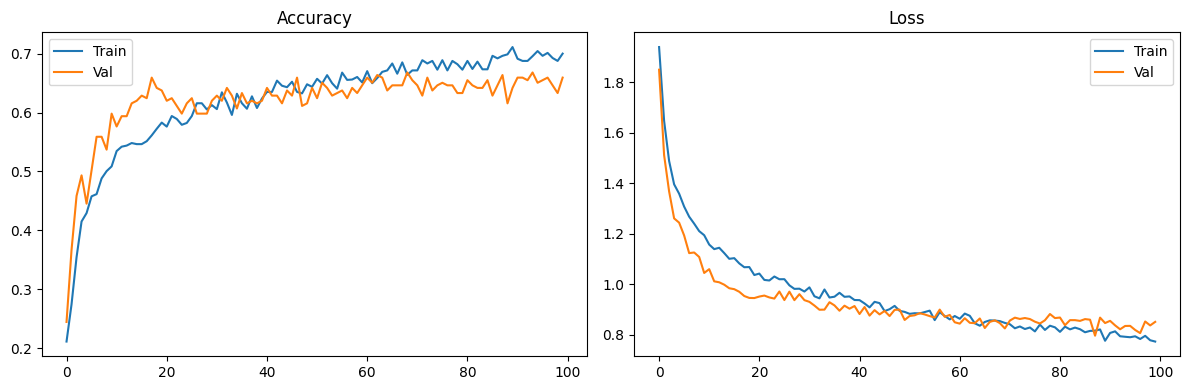

14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.6992 - loss: 0.7383

2025-10-10 13:07:38.665777: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1722', 224 bytes spill stores, 224 bytes spill loads

2025-10-10 13:07:38.715503: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1722', 4 bytes spill stores, 4 bytes spill loads

2025-10-10 13:07:38.746496: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1722', 132 bytes spill stores, 132 bytes spill loads

2025-10-10 13:07:38.964085: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1722', 4444 bytes spill stores, 4156 bytes spill loads

2025-10-10 13:07:38.965250: I exte

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 334ms/step - accuracy: 0.6869 - loss: 0.7685

Test Accuracy : 0.6009
Test Loss     : 0.9803
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.91      0.69       101
           1       0.42      0.47      0.45        99
           2       0.55      0.30      0.39        94
           3       0.94      0.66      0.78        89
           4       0.73      0.65      0.69        83

    accuracy                           0.60       466
   macro avg       0.64      0.60      0.60       466
weighted avg       0.63      0.60      0.59       466

Precision (weighted): 0.6289
Recall    (weighted): 0.6009
F1 score  (weighted): 0.5926


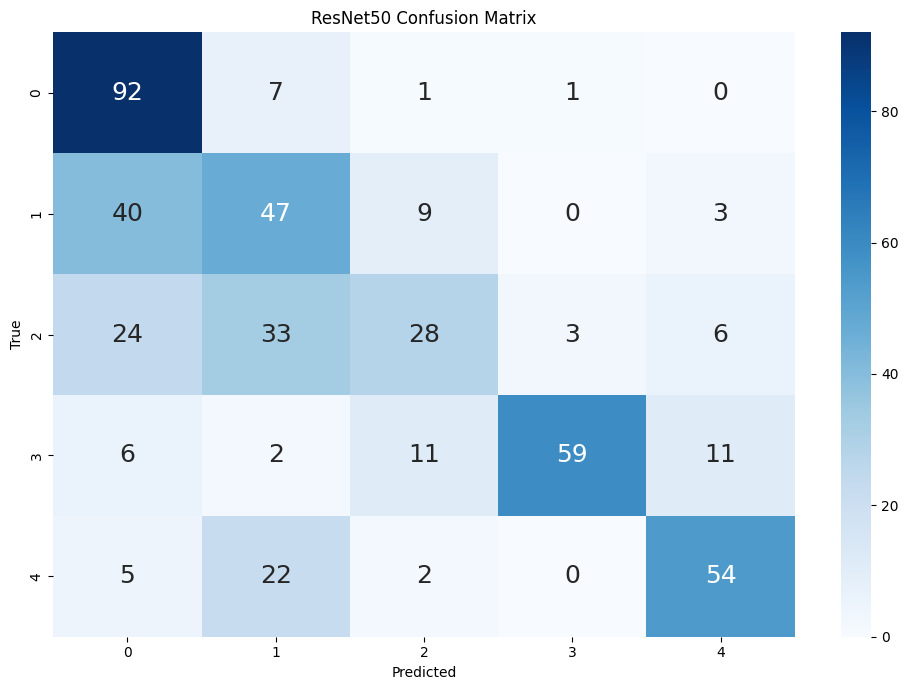

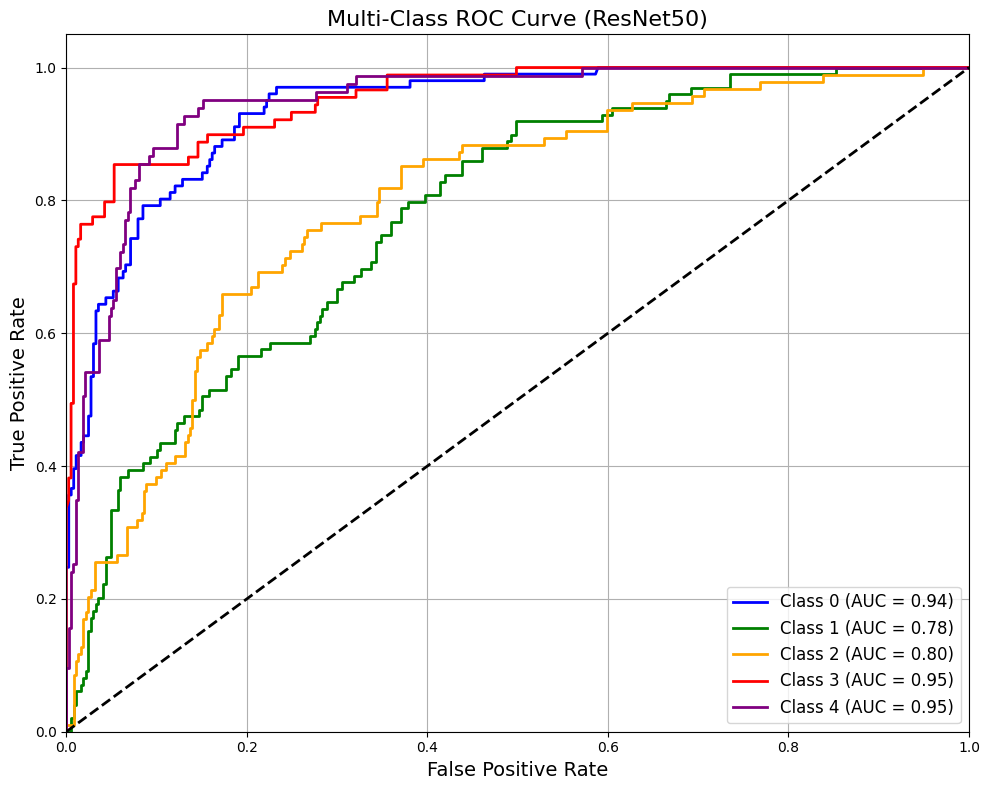

In [2]:
"""
Baseline ResNet50 model for 5-class knee-X-ray classification.

Expected directory layout:
E:/FA011/MSC/SplittedDataset/{train|val|test}/<class_name>/*.png|*.jpg
"""

# ─────────────────────── 1. IMPORTS ──────────────────────────────
import os, cv2, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize

# ─────────────────────── 2. PARAMETERS ───────────────────────────
TRAIN_DIR = '/mnt/d/FA019/new/SplittedDataset/train'
VAL_DIR   ='/mnt/d/FA019/new/SplittedDataset/val'
TEST_DIR  = '/mnt/d/FA019/new/SplittedDataset/test'


IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(os.listdir(TRAIN_DIR))

# ─────────────────── 3. BPHE PREPROCESS FUNCTION ─────────────────
def bphe_rgb(img):
    """Apply BPHE and ResNet50 preprocessing."""
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

    ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(ycrcb)
    y_eq = cv2.equalizeHist(y)
    img_eq = cv2.cvtColor(cv2.merge((y_eq, cr, cb)), cv2.COLOR_YCrCb2RGB)
    return preprocess_input(img_eq.astype(np.float32))

# ──────────────── 4. IMAGE GENERATORS ────────────────────────────
train_gen = ImageDataGenerator(
    preprocessing_function=bphe_rgb,
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True,
    brightness_range=[0.8, 1.2], fill_mode='nearest'
).flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical')

val_gen = ImageDataGenerator(preprocessing_function=bphe_rgb
).flow_from_directory(VAL_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical')

test_gen = ImageDataGenerator(preprocessing_function=bphe_rgb
).flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical',
                      shuffle=False)

# ────────────────────── 5. BUILD MODEL ───────────────────────────
base = ResNet50(weights='imagenet', include_top=False,
                input_shape=IMG_SIZE + (3,))

x = base.output
x = GlobalAveragePooling2D()(x)
pred = Dense(NUM_CLASSES, activation='softmax', name='pred')(x)
model = Model(inputs=base.input, outputs=pred)

# Freeze base layers
for layer in base.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ──────────────────── 6. TRAINING ───────────────────────────────
history = model.fit(
    train_gen,
    epochs=100,
    validation_data=val_gen
)

# ─────────────── 7. ACCURACY & LOSS PLOTS ───────────────────────
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ─────────────── 8. EVALUATION ──────────────────────────────────
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

# Predictions
test_gen.reset()
prob = model.predict(test_gen)
y_pred = np.argmax(prob, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# Metrics
conf_mat = confusion_matrix(y_true, y_pred)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print(f"Precision (weighted): {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall    (weighted): {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1 score  (weighted): {f1_score(y_true, y_pred, average='weighted'):.4f}")

# Confusion-matrix heat-map
plt.figure(figsize=(10,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size':18})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('ResNet50 Confusion Matrix')
plt.tight_layout()
plt.show()

# ─────────────── 9. ROC CURVE ────────────────────────────────────
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
y_score = prob

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'orange', 'red', 'purple']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Multi-Class ROC Curve (ResNet50)', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 42,668,421 (162.77 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 42,658,176 (162.73 MB)

/mnt/d/FA011/tf_gpu_env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 26s 379ms/step - accuracy: 0.2309 - loss: 1.8742 - val_accuracy: 0.2707 - val_loss: 1.6882
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 212ms/step - accuracy: 0.3086 - loss: 1.6104 - val_accuracy: 0.2926 - val_loss: 1.4950
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - accuracy: 0.3473 - loss: 1.4680 - val_accuracy: 0.3406 - val_loss: 1.3770
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 257ms/step - accuracy: 0.4100 - loss: 1.3753 - val_accuracy: 0.3930 - val_loss: 1.3240
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - accuracy: 0.4199 - loss: 1.3422 - val_accuracy: 0.4410 - val_loss: 1.2922
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - accuracy: 0.4798 - loss: 1.2837 - val_accuracy: 0.4454 - val_loss: 1.2819
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - accuracy: 0.4699 - loss: 1.2519 - val_accuracy: 0.4672 - val_loss: 1.2330
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 295ms/step - accuracy: 0.4769 - loss: 1.2271 - 

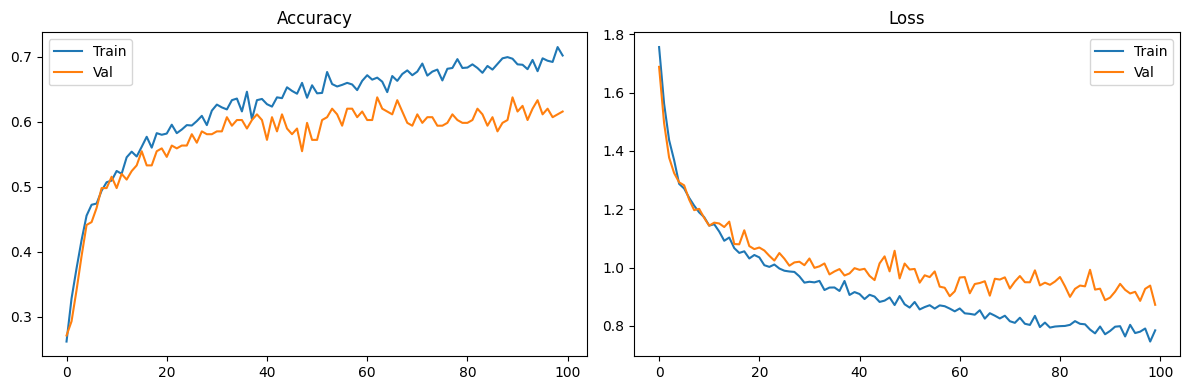

15/15 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.6869 - loss: 0.7884

Test Accuracy : 0.6009
Test Loss     : 0.9753
15/15 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step 

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.93      0.67       101
           1       0.46      0.40      0.43        99
           2       0.62      0.37      0.47        94
           3       0.85      0.67      0.75        89
           4       0.72      0.61      0.66        83

    accuracy                           0.60       466
   macro avg       0.63      0.60      0.60       466
weighted avg       0.63      0.60      0.59       466

Precision (weighted): 0.6256
Recall    (weighted): 0.6009
F1 score  (weighted): 0.5912


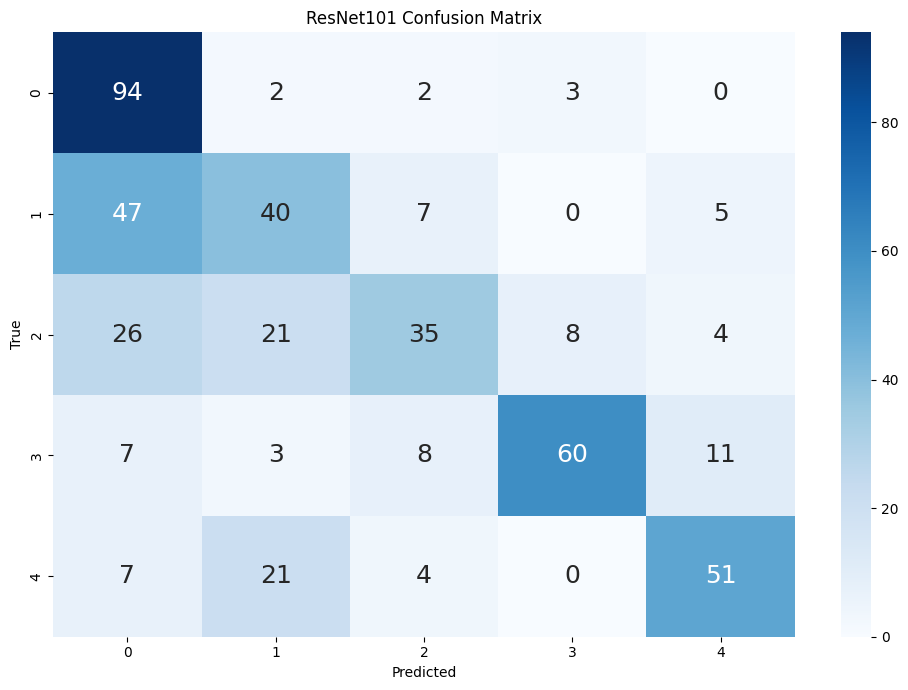

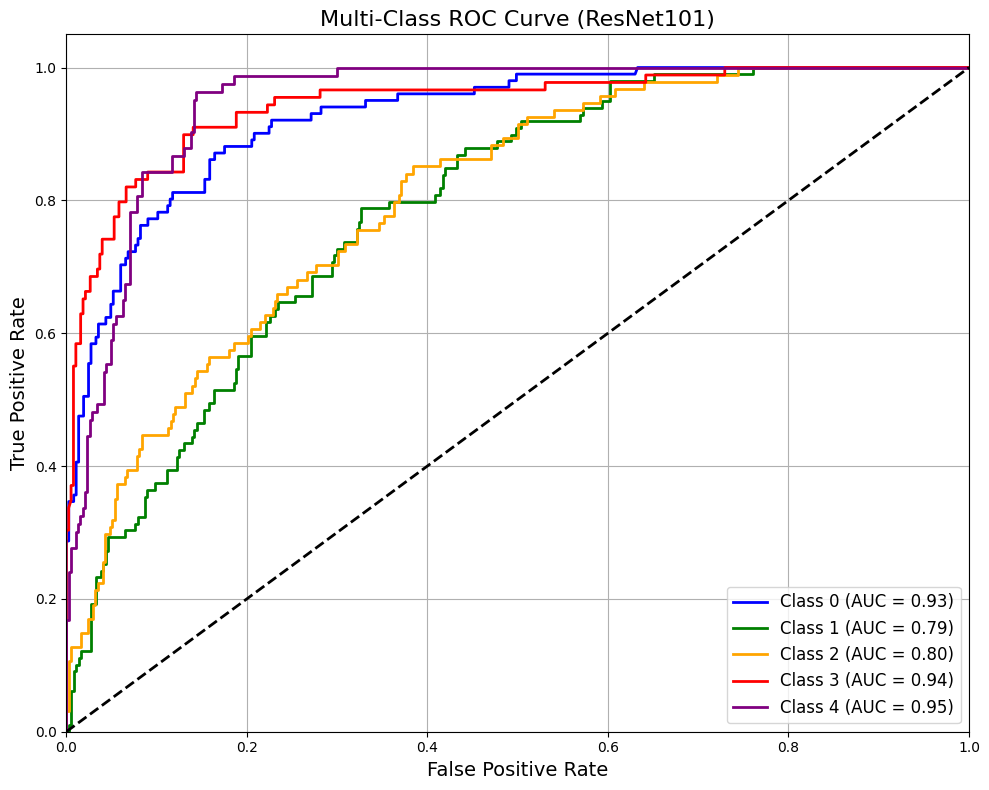

In [3]:
"""
Baseline ResNet101 model for 5-class knee-X-ray classification.

Expected directory layout:
E:/FA011/MSC/SplittedDataset/{train|val|test}/<class_name>/*.png|*.jpg
"""

# ─────────────────────── 1. IMPORTS ──────────────────────────────
import os, cv2, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet101

from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize

# ─────────────────────── 2. PARAMETERS ───────────────────────────
TRAIN_DIR = '/mnt/d/FA019/new/SplittedDataset/train'
VAL_DIR   ='/mnt/d/FA019/new/SplittedDataset/val'
TEST_DIR  = '/mnt/d/FA019/new/SplittedDataset/test'


IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(os.listdir(TRAIN_DIR))

# ─────────────────── 3. BPHE PREPROCESS FUNCTION ─────────────────
def bphe_rgb(img):
    """Apply BPHE and ResNet101 preprocessing."""
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

    ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(ycrcb)
    y_eq = cv2.equalizeHist(y)
    img_eq = cv2.cvtColor(cv2.merge((y_eq, cr, cb)), cv2.COLOR_YCrCb2RGB)
    return preprocess_input(img_eq.astype(np.float32))

# ──────────────── 4. IMAGE GENERATORS ────────────────────────────
train_gen = ImageDataGenerator(
    preprocessing_function=bphe_rgb,
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True,
    brightness_range=[0.8, 1.2], fill_mode='nearest'
).flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical')

val_gen = ImageDataGenerator(preprocessing_function=bphe_rgb
).flow_from_directory(VAL_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical')

test_gen = ImageDataGenerator(preprocessing_function=bphe_rgb
).flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical',
                      shuffle=False)

# ────────────────────── 5. BUILD MODEL ───────────────────────────
base = ResNet101(weights='imagenet', include_top=False,
                input_shape=IMG_SIZE + (3,))

x = base.output
x = GlobalAveragePooling2D()(x)
pred = Dense(NUM_CLASSES, activation='softmax', name='pred')(x)
model = Model(inputs=base.input, outputs=pred)

# Freeze base layers
for layer in base.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ──────────────────── 6. TRAINING ───────────────────────────────
history = model.fit(
    train_gen,
    epochs=100,
    validation_data=val_gen
)

# ─────────────── 7. ACCURACY & LOSS PLOTS ───────────────────────
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ─────────────── 8. EVALUATION ──────────────────────────────────
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

# Predictions
test_gen.reset()
prob = model.predict(test_gen)
y_pred = np.argmax(prob, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# Metrics
conf_mat = confusion_matrix(y_true, y_pred)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print(f"Precision (weighted): {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall    (weighted): {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1 score  (weighted): {f1_score(y_true, y_pred, average='weighted'):.4f}")

# Confusion-matrix heat-map
plt.figure(figsize=(10,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size':18})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('ResNet101 Confusion Matrix')
plt.tight_layout()
plt.show()

# ─────────────── 9. ROC CURVE ────────────────────────────────────
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
y_score = prob

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'orange', 'red', 'purple']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Multi-Class ROC Curve (ResNet101)', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()
